# DermAssist Image Processing

This notebook processes PH2 skin images.

Input images are taken only from:

- `PH2/trainx/`
- `PH2/ph2_dataset/trainx/`

The original images are not changed. Processed images are saved in `outputs/`.

### Load Libraries
Load the libraries needed for this project.

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from hashlib import md5
from skimage.metrics import structural_similarity as ssim

plt.rcParams["figure.figsize"] = (12, 5)

### Find the Project Folder
Find the project folder without using an absolute path.

In [46]:
# Find project folder
if (Path(".") / "PH2").exists():
    BASE_DIR = Path(".")
elif (Path("..") / "PH2").exists():
    BASE_DIR = Path("..")
else:
    raise FileNotFoundError("PH2 folder was not found.")

trainx1 = BASE_DIR / "PH2" / "trainx"
trainx2 = BASE_DIR / "PH2" / "ph2_dataset" / "trainx"

output_dir = BASE_DIR / "outputs"
denoised_dir = output_dir / "denoised"
hair_masks_dir = output_dir / "hair_masks"
hair_removed_dir = output_dir / "hair_removed"
final_dir = output_dir / "final"

for folder in [denoised_dir, hair_masks_dir, hair_removed_dir, final_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", BASE_DIR.resolve())
print("Input folder 1:", trainx1)
print("Input folder 2:", trainx2)

Project folder: D:\CV\DermAssist
Input folder 1: ..\PH2\trainx
Input folder 2: ..\PH2\ph2_dataset\trainx


### Check Dataset Folders
Check the two required input folders. `trainy` is not used as an image input folder.

In [47]:
if not trainx1.exists():
    raise FileNotFoundError(f"Missing folder: {trainx1}")

if not trainx2.exists():
    raise FileNotFoundError(f"Missing folder: {trainx2}")

image_ext = {".bmp", ".jpg", ".jpeg", ".png", ".tif", ".tiff"}

files1 = sorted([p for p in trainx1.iterdir() if p.is_file() and p.suffix.lower() in image_ext])
files2 = sorted([p for p in trainx2.iterdir() if p.is_file() and p.suffix.lower() in image_ext])

print("Images in PH2/trainx:", len(files1))
print("Images in PH2/ph2_dataset/trainx:", len(files2))
print("Total before duplicate check:", len(files1) + len(files2))

print("\nSample names from first folder:")
print([p.name for p in files1[:5]])

print("\nSample names from second folder:")
print([p.name for p in files2[:5]])

Images in PH2/trainx: 200
Images in PH2/ph2_dataset/trainx: 200
Total before duplicate check: 400

Sample names from first folder:
['IMD002.bmp', 'IMD003.bmp', 'IMD004.bmp', 'IMD006.bmp', 'IMD008.bmp']

Sample names from second folder:
['IMD002.bmp', 'IMD003.bmp', 'IMD004.bmp', 'IMD006.bmp', 'IMD008.bmp']


### Build the Input List
Use only the two `trainx` folders. Exact duplicate files are removed by file hash.

In [48]:
input_images = []
seen_hashes = set()

for folder_files in [files1, files2]:
    for file in folder_files:
        file_hash = md5(file.read_bytes()).hexdigest()
        if file_hash not in seen_hashes:
            input_images.append(file)
            seen_hashes.add(file_hash)

input_images = sorted(input_images, key=lambda x: x.name)

print("Unique input images:", len(input_images))
print("First 10 files:")
for file in input_images[:10]:
    print(file.name)

Unique input images: 200
First 10 files:
IMD002.bmp
IMD003.bmp
IMD004.bmp
IMD006.bmp
IMD008.bmp
IMD009.bmp
IMD010.bmp
IMD013.bmp
IMD014.bmp
IMD015.bmp


### Show Original Images
Display four sample images from the input list.

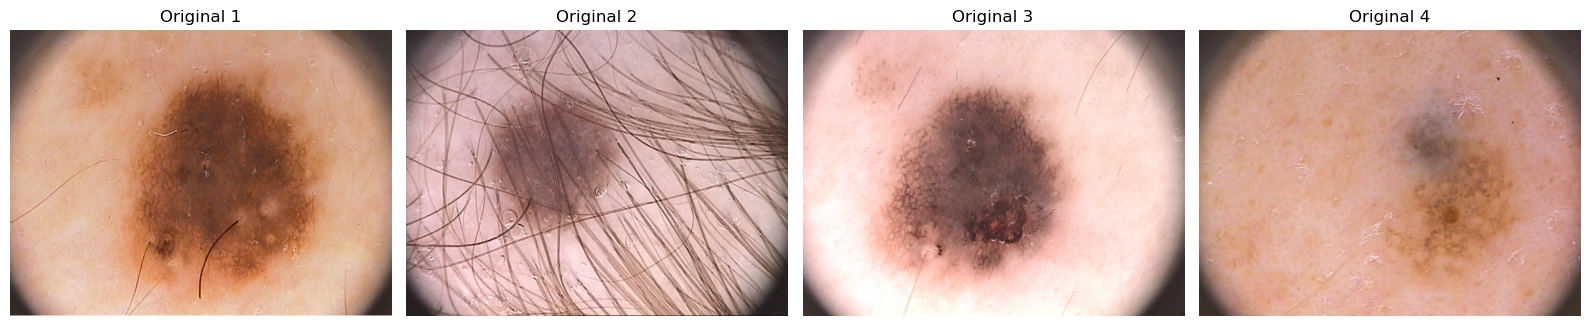

In [49]:
sample_files = input_images[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, file in enumerate(sample_files):
    image = cv2.imread(str(file))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].set_title(f"Original {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Denoising Functions
Create simple spatial and Fourier denoising methods.

In [50]:
def mean_filter(image, size):
    return cv2.blur(image, (size, size))

def gaussian_filter(image, size):
    return cv2.GaussianBlur(image, (size, size), 0)

def median_filter(image, size):
    return cv2.medianBlur(image, size)

def bilateral_filter(image):
    return cv2.bilateralFilter(image, 9, 50, 50)

def fourier_filter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f)

    rows, cols = gray.shape
    y, x = np.ogrid[:rows, :cols]
    center_y, center_x = rows // 2, cols // 2
    sigma = min(rows, cols) / 8

    mask = np.exp(-((x - center_x) ** 2 + (y - center_y) ** 2) / (2 * sigma ** 2))

    filtered = f_shift * mask
    result = np.fft.ifft2(np.fft.ifftshift(filtered))
    result = np.abs(result)
    result = cv2.normalize(result, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)

def apply_denoise(image, method):
    if method == "Mean 3x3":
        return mean_filter(image, 3)
    if method == "Mean 5x5":
        return mean_filter(image, 5)
    if method == "Gaussian 3x3":
        return gaussian_filter(image, 3)
    if method == "Gaussian 5x5":
        return gaussian_filter(image, 5)
    if method == "Median 3x3":
        return median_filter(image, 3)
    if method == "Median 5x5":
        return median_filter(image, 5)
    if method == "Bilateral":
        return bilateral_filter(image)
    if method == "Fourier":
        return fourier_filter(image)
    raise ValueError("Unknown denoising method.")

### Test Denoising Methods
Test several methods on a small sample before processing the full dataset.

In [51]:
test_files = input_images[:10]

methods = [
    "Mean 3x3", "Mean 5x5",
    "Gaussian 3x3", "Gaussian 5x5",
    "Median 3x3", "Median 5x5",
    "Bilateral", "Fourier"
]

test_results = []

def edge_ratio(original, processed):
    original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    processed_gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)

    edge1 = cv2.Canny(original_gray, 100, 200)
    edge2 = cv2.Canny(processed_gray, 100, 200)

    n1 = np.count_nonzero(edge1)
    n2 = np.count_nonzero(edge2)

    if n1 == 0:
        return np.nan

    return n2 / n1

for file in test_files:
    image = cv2.imread(str(file))

    for method in methods:
        result = apply_denoise(image, method)

        original_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        result_gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

        test_results.append({
            "Image": file.name,
            "Method": method,
            "Edge Ratio": edge_ratio(image, result),
            "SSIM to Original": ssim(original_gray, result_gray, data_range=255)
        })

denoise_test_df = pd.DataFrame(test_results)
summary = denoise_test_df.groupby("Method")[["Edge Ratio", "SSIM to Original"]].mean().reset_index()

summary

,Method,Edge Ratio,SSIM to Original
0,Bilateral,0.530800,0.853863
1,Fourier,0.444564,0.822460
2,Gaussian 3x3,0.548586,0.923887
3,Gaussian 5x5,0.344963,0.881110
4,Mean 3x3,0.460556,0.885834
5,Mean 5x5,0.145787,0.804351
6,Median 3x3,0.588943,0.889261
7,Median 5x5,0.300008,0.814119


### Denoising Metrics
The PH2 `trainy` files are lesion masks, not clean versions of the input images. Therefore they are not used as Ground Truth for MSE, RMSE, PSNR, or SSIM.

In [52]:
# No clean Ground Truth image is available in the selected input structure.
# Do not use lesion masks as clean image references.

metric_results = pd.DataFrame(
    columns=["Method", "MSE", "RMSE", "PSNR", "SSIM"]
)

metric_results.loc[0] = ["No valid clean reference", np.nan, np.nan, np.nan, np.nan]
metric_results

,Method,MSE,RMSE,PSNR,SSIM
0,No valid clean reference,NaN,NaN,NaN,NaN


### Denoising Comparison
Compare the tested methods visually and by edge preservation. Choose the method after seeing the actual results.

In [53]:
best_view = summary.sort_values("Edge Ratio", ascending=False)
best_view

,Method,Edge Ratio,SSIM to Original
6,Median 3x3,0.588943,0.889261
2,Gaussian 3x3,0.548586,0.923887
0,Bilateral,0.530800,0.853863
4,Mean 3x3,0.460556,0.885834
1,Fourier,0.444564,0.822460
3,Gaussian 5x5,0.344963,0.881110
7,Median 5x5,0.300008,0.814119
5,Mean 5x5,0.145787,0.804351


### Show Denoising Comparison
Show the main methods on one sample image.

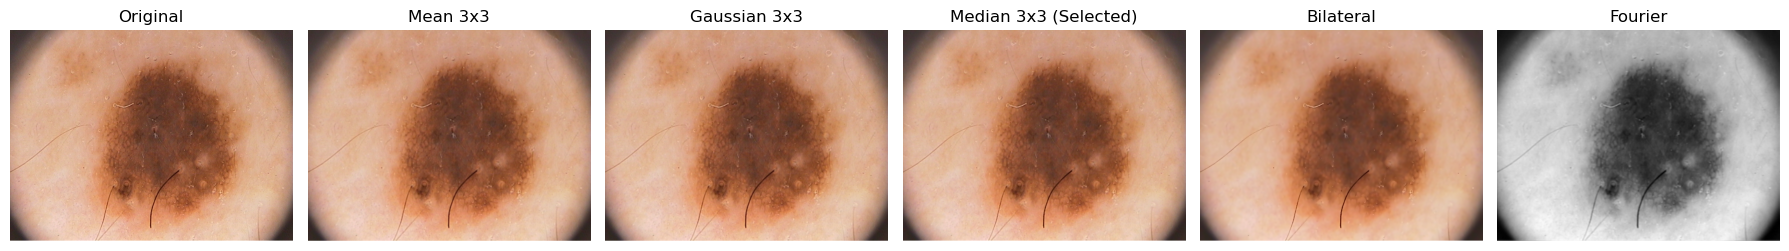

In [54]:
file = input_images[0]
image = cv2.imread(str(file))

show_methods = [
    "Original",
    "Mean 3x3",
    "Gaussian 3x3",
    "Median 3x3",
    "Bilateral",
    "Fourier"
]

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for i, method in enumerate(show_methods):

    if method == "Original":
        result = image
    else:
        result = apply_denoise(image, method)

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    axes[i].imshow(result)

    if method == FINAL_DENOISE_METHOD:
        axes[i].set_title(method + " (Selected)")
    else:
        axes[i].set_title(method)

    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Select Denoising Method
Set the final method after checking the table and images above.

In [55]:
# Select the best denoising method automatically

best_view = summary.sort_values(
    ["Edge Ratio", "SSIM to Original"],
    ascending=[False, False]
)

FINAL_DENOISE_METHOD = best_view.iloc[0]["Method"]

print("Selected method:", FINAL_DENOISE_METHOD)

Selected method: Median 3x3


### Save Denoised Images
Apply the selected method to all unique input images and save them in `outputs/denoised/`.

In [56]:
for i, file in enumerate(input_images):
    image = cv2.imread(str(file))
    result = apply_denoise(image, FINAL_DENOISE_METHOD)

    output_file = denoised_dir / file.name
    cv2.imwrite(str(output_file), result)

    if (i + 1) % 50 == 0 or i + 1 == len(input_images):
        print("Processed:", i + 1, "/", len(input_images))

print("Denoised images saved in:", denoised_dir)

Processed: 50 / 200
Processed: 100 / 200
Processed: 150 / 200
Processed: 200 / 200
Denoised images saved in: ..\outputs\denoised


### Show Denoising Results
Show four original and denoised image pairs.

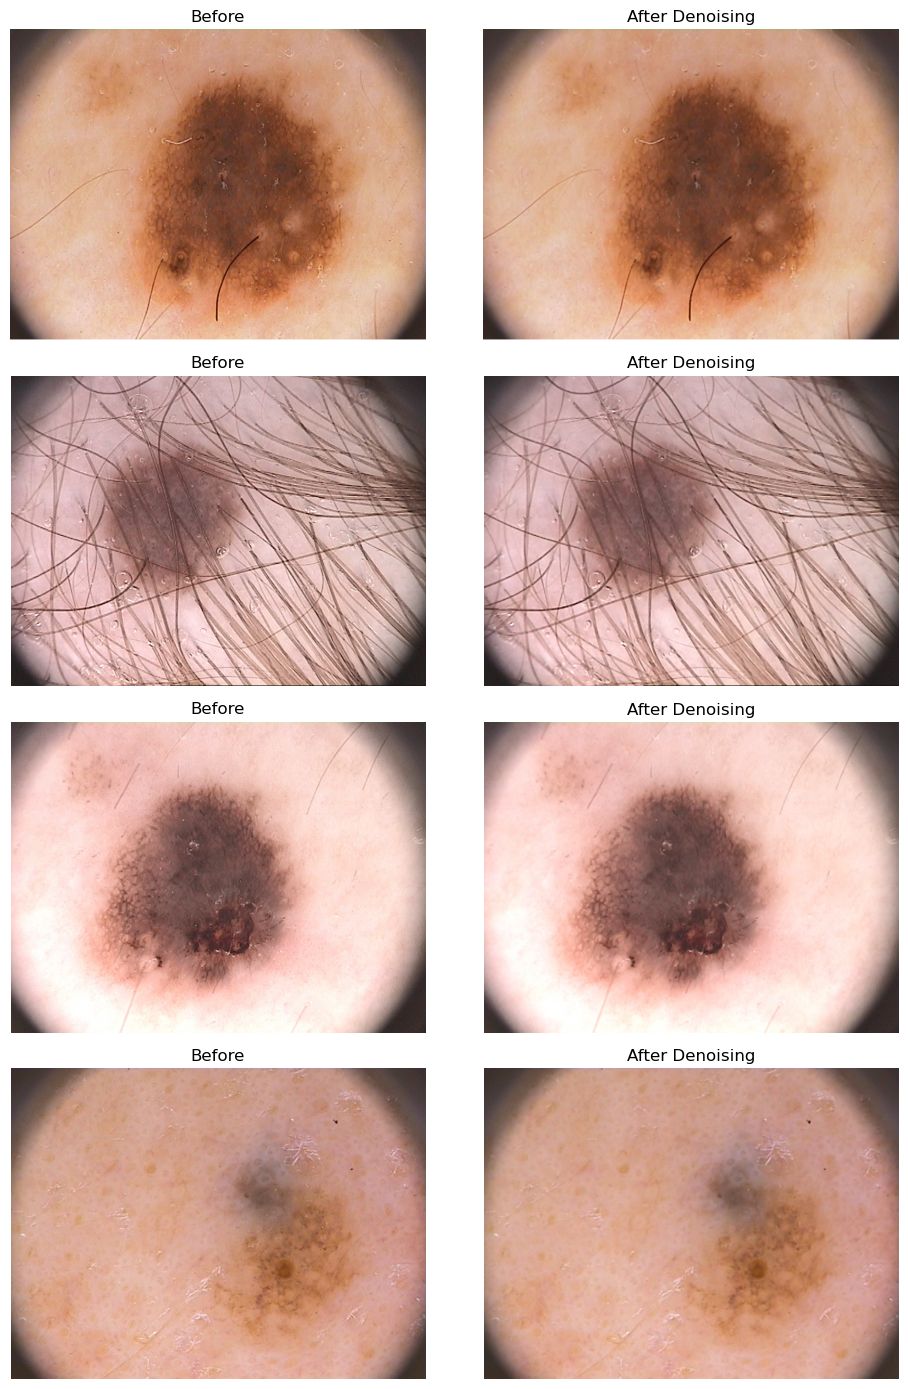

In [57]:
sample_files = input_images[:4]

fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for i, file in enumerate(sample_files):
    original = cv2.imread(str(file))
    denoised = cv2.imread(str(denoised_dir / file.name))

    axes[i, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Before")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("After Denoising")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### Hair Detection Functions
Detect dark and bright hair.

In [58]:
def dark_hair_mask(image, kernel_size=9):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)
    )

    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(black_hat, 12, 255, cv2.THRESH_BINARY)

    return mask

def bright_hair_mask(image, kernel_size=9):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel = lab[:, :, 0]

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (kernel_size, kernel_size)
    )

    top_hat = cv2.morphologyEx(l_channel, cv2.MORPH_TOPHAT, kernel)
    _, mask = cv2.threshold(top_hat, 18, 255, cv2.THRESH_BINARY)

    return mask

def clean_hair_mask(mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

def get_lesion_mask(image_file):
    # Use trainy only as a lesion protection mask.
    name = image_file.stem + "_lesion" + image_file.suffix

    possible = [
        image_file.parent.parent / "trainy" / name,
        image_file.parent.parent.parent / "trainy" / name
    ]

    for mask_file in possible:
        if mask_file.exists():
            mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
            if mask is not None and mask.shape[:2] == cv2.imread(str(image_file)).shape[:2]:
                return mask

    return None

def build_hair_mask(image, image_file):
    dark = dark_hair_mask(image, 9)
    bright = bright_hair_mask(image, 9)

    mask = cv2.bitwise_or(dark, bright)
    mask = clean_hair_mask(mask)

    lesion = get_lesion_mask(image_file)

    if lesion is not None:
        # Keep the lesion area protected.
        lesion_binary = lesion > 0
        mask[lesion_binary] = 0

    return mask

### Show Hair Mask
Show dark/bright hair detection and the final mask.

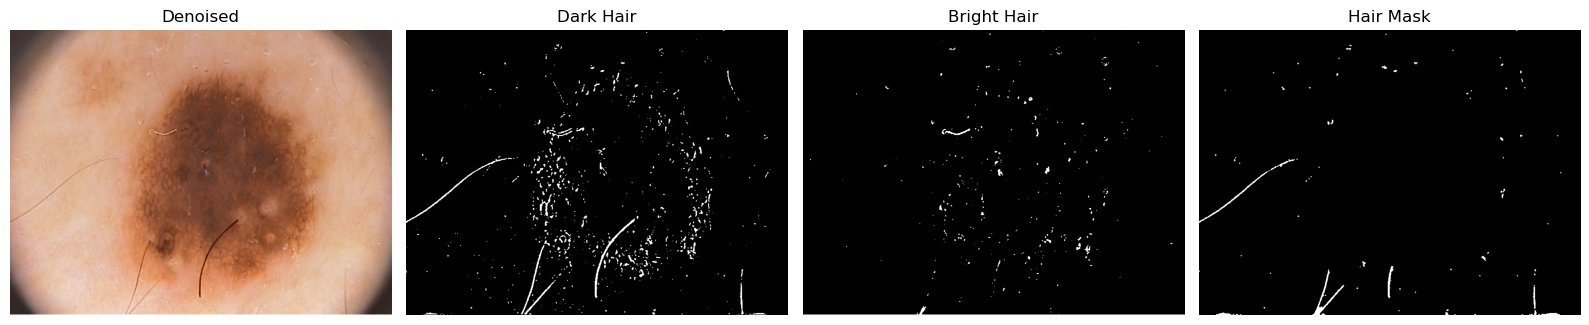

In [59]:
file = input_images[0]
image = cv2.imread(str(denoised_dir / file.name))

dark = dark_hair_mask(image)
bright = bright_hair_mask(image)
hair_mask = build_hair_mask(image, file)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Denoised")
axes[0].axis("off")

axes[1].imshow(dark, cmap="gray")
axes[1].set_title("Dark Hair")
axes[1].axis("off")

axes[2].imshow(bright, cmap="gray")
axes[2].set_title("Bright Hair")
axes[2].axis("off")

axes[3].imshow(hair_mask, cmap="gray")
axes[3].set_title("Hair Mask")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Hair Removal Test
Test hair removal on sample images and check lesion and skin preservation.

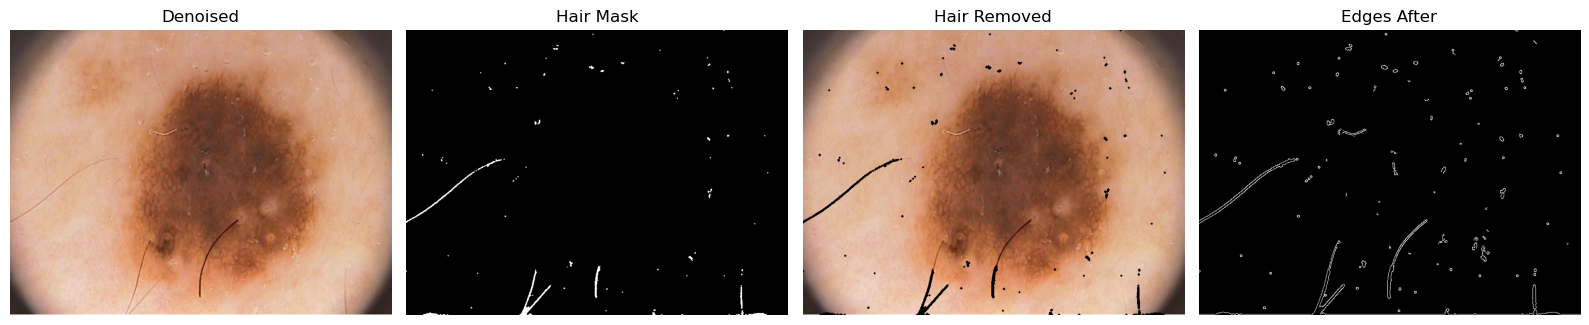

In [60]:
def remove_hair(image, mask):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.dilate(mask, kernel, iterations=1)

    result = image.copy()
    result[mask > 0] = 0
    return result

file = input_images[0]
image = cv2.imread(str(denoised_dir / file.name))
mask = build_hair_mask(image, file)
hair_removed = remove_hair(image, mask)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Denoised")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Hair Mask")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(hair_removed, cv2.COLOR_BGR2RGB))
axes[2].set_title("Hair Removed")
axes[2].axis("off")

edges_before = cv2.Canny(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY), 100, 200)
edges_after = cv2.Canny(cv2.cvtColor(hair_removed, cv2.COLOR_BGR2GRAY), 100, 200)
axes[3].imshow(edges_after, cmap="gray")
axes[3].set_title("Edges After")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Save Hair Masks and Hair-Removed Images
Process all denoised images and save the masks and results.

In [61]:
for i, file in enumerate(input_images):
    denoised_file = denoised_dir / file.name
    image = cv2.imread(str(denoised_file))

    mask = build_hair_mask(image, file)
    removed = remove_hair(image, mask)

    cv2.imwrite(str(hair_masks_dir / file.name), mask)
    cv2.imwrite(str(hair_removed_dir / file.name), removed)

    if (i + 1) % 50 == 0 or i + 1 == len(input_images):
        print("Processed:", i + 1, "/", len(input_images))

print("Hair masks saved in:", hair_masks_dir)
print("Hair-removed images saved in:", hair_removed_dir)

Processed: 50 / 200
Processed: 100 / 200
Processed: 150 / 200
Processed: 200 / 200
Hair masks saved in: ..\outputs\hair_masks
Hair-removed images saved in: ..\outputs\hair_removed


### Show Hair Removal Results
Show four before and after examples.

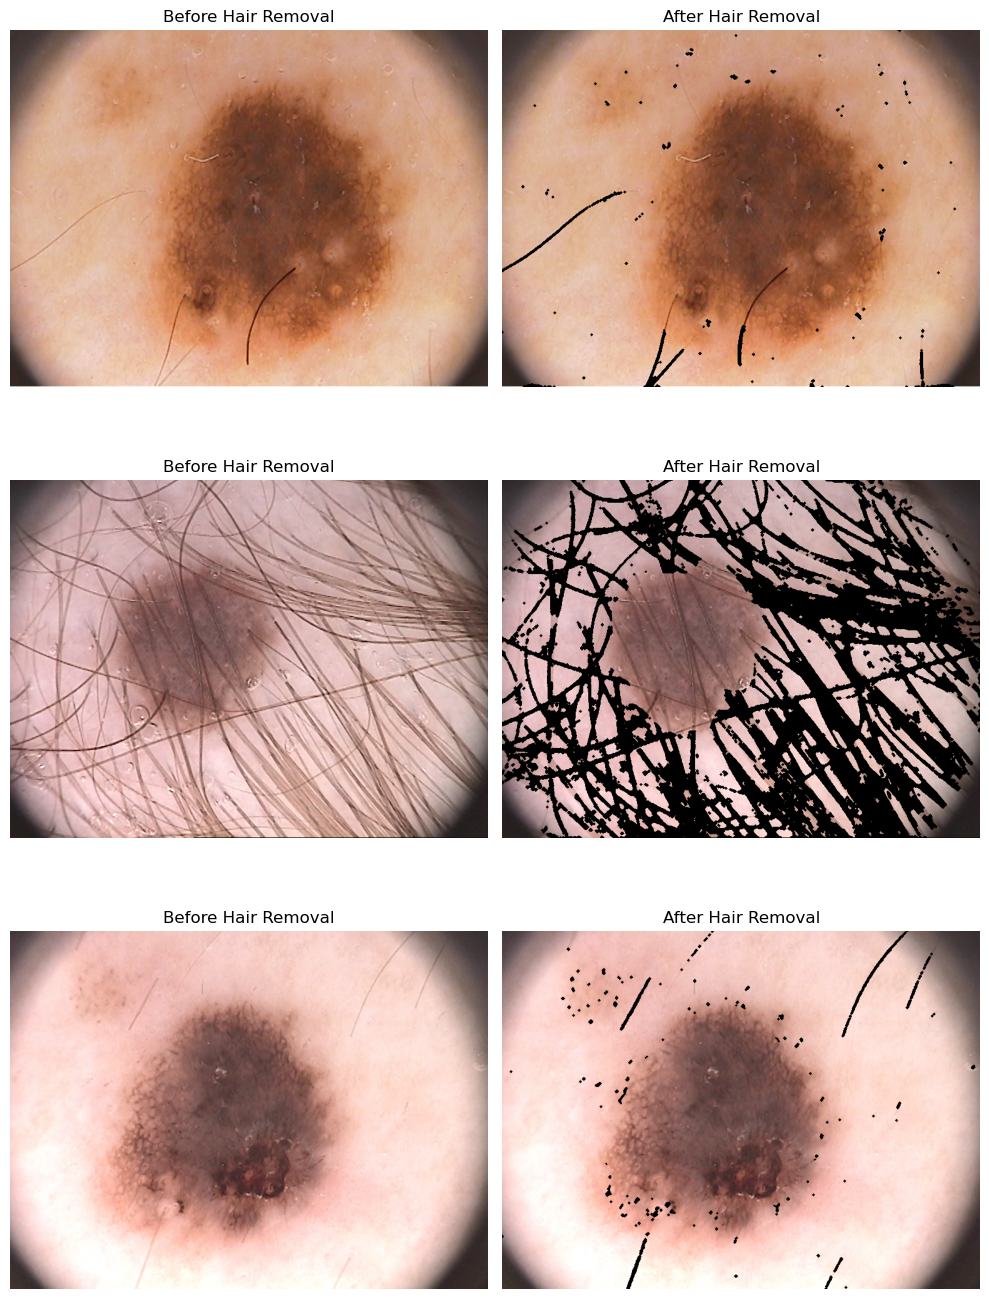

In [62]:
sample_files = input_images[:3]

fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for i, file in enumerate(sample_files):
    before = cv2.imread(str(denoised_dir / file.name))
    after = cv2.imread(str(hair_removed_dir / file.name))

    axes[i, 0].imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Before Hair Removal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("After Hair Removal")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### Inpainting Test
Compare Telea and Navier-Stokes on the same hair masks.

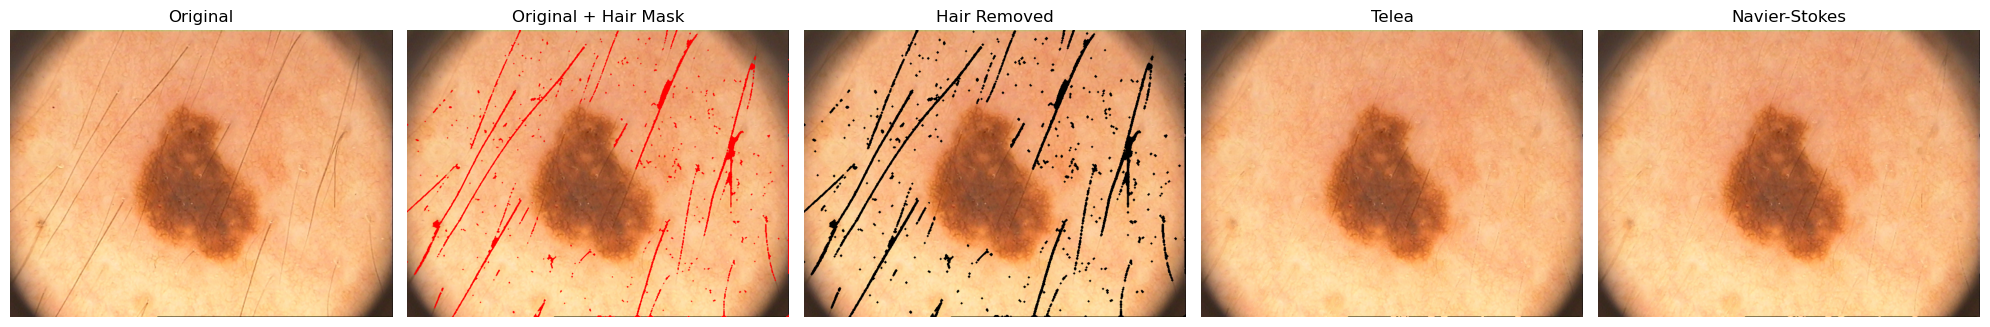

In [63]:
def inpaint_image(image, mask, method):

    if method == "Telea":
        return cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

    if method == "Navier-Stokes":
        return cv2.inpaint(image, mask, 3, cv2.INPAINT_NS)

    raise ValueError("Unknown inpainting method.")


file = input_images[155]

# Read the denoised image
image = cv2.imread(str(denoised_dir / file.name))

# Read the hair mask
mask = cv2.imread(
    str(hair_masks_dir / file.name),
    cv2.IMREAD_GRAYSCALE
)

# Remove hair using the mask
hair_removed = remove_hair(image, mask)

# Inpaint the removed hair areas
telea = inpaint_image(image, mask, "Telea")
ns = inpaint_image(image, mask, "Navier-Stokes")


fig, axes = plt.subplots(1, 5, figsize=(20, 4))


# 1. Original image
axes[0].imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)
axes[0].set_title("Original")
axes[0].axis("off")


# 2. Original + Hair Mask
image_with_mask = image.copy()
image_with_mask[mask > 0] = [0, 0, 255]

axes[1].imshow(
    cv2.cvtColor(image_with_mask, cv2.COLOR_BGR2RGB)
)
axes[1].set_title("Original + Hair Mask")
axes[1].axis("off")


# 3. Hair Removed
axes[2].imshow(
    cv2.cvtColor(hair_removed, cv2.COLOR_BGR2RGB)
)
axes[2].set_title("Hair Removed")
axes[2].axis("off")


# 4. Telea
axes[3].imshow(
    cv2.cvtColor(telea, cv2.COLOR_BGR2RGB)
)
axes[3].set_title("Telea")
axes[3].axis("off")


# 5. Navier-Stokes
axes[4].imshow(
    cv2.cvtColor(ns, cv2.COLOR_BGR2RGB)
)
axes[4].set_title("Navier-Stokes")
axes[4].axis("off")


plt.tight_layout()
plt.show()

### Select Inpainting Method
Choose the method after checking the real examples above.

In [64]:
# Test both inpainting methods and select the better one automatically

def inpaint_score(image, mask, method):
    result = inpaint_image(image, mask, method)

    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    # Calculate edge strength inside the inpainted area
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    gradient = np.sqrt(gx**2 + gy**2)

    area = mask > 0

    if np.sum(area) == 0:
        return float("inf")

    return np.mean(gradient[area])


methods = ["Telea", "Navier-Stokes"]

scores = {
    "Telea": [],
    "Navier-Stokes": []
}

# Test several real images
test_files = input_images[:10]

for file in test_files:

    image = cv2.imread(str(denoised_dir / file.name))
    mask = cv2.imread(
        str(hair_masks_dir / file.name),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None or mask is None:
        continue

    for method in methods:
        score = inpaint_score(image, mask, method)
        scores[method].append(score)


# Calculate the average score
average_scores = {
    method: np.mean(scores[method])
    for method in methods
    if len(scores[method]) > 0
}

# Lower score means smoother inpainting
FINAL_INPAINT_METHOD = min(
    average_scores,
    key=average_scores.get
)

print("Inpainting results:")
for method, score in average_scores.items():
    print(method, ":", round(score, 4))

print("Selected method:", FINAL_INPAINT_METHOD)

Inpainting results:
Telea : 17.9802
Navier-Stokes : 19.4148
Selected method: Telea


### Save Final Images
Apply the selected inpainting method to all hair-removed images.

In [65]:
for i, file in enumerate(input_images):
    hair_removed_file = hair_removed_dir / file.name
    mask_file = hair_masks_dir / file.name

    image = cv2.imread(str(hair_removed_file))
    mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)

    final_image = inpaint_image(image, mask, FINAL_INPAINT_METHOD)

    cv2.imwrite(str(final_dir / file.name), final_image)

    if (i + 1) % 50 == 0 or i + 1 == len(input_images):
        print("Processed:", i + 1, "/", len(input_images))

print("Final images saved in:", final_dir)

Processed: 50 / 200
Processed: 100 / 200
Processed: 150 / 200
Processed: 200 / 200
Final images saved in: ..\outputs\final


### Final Comparison
Show the complete pipeline for four images.

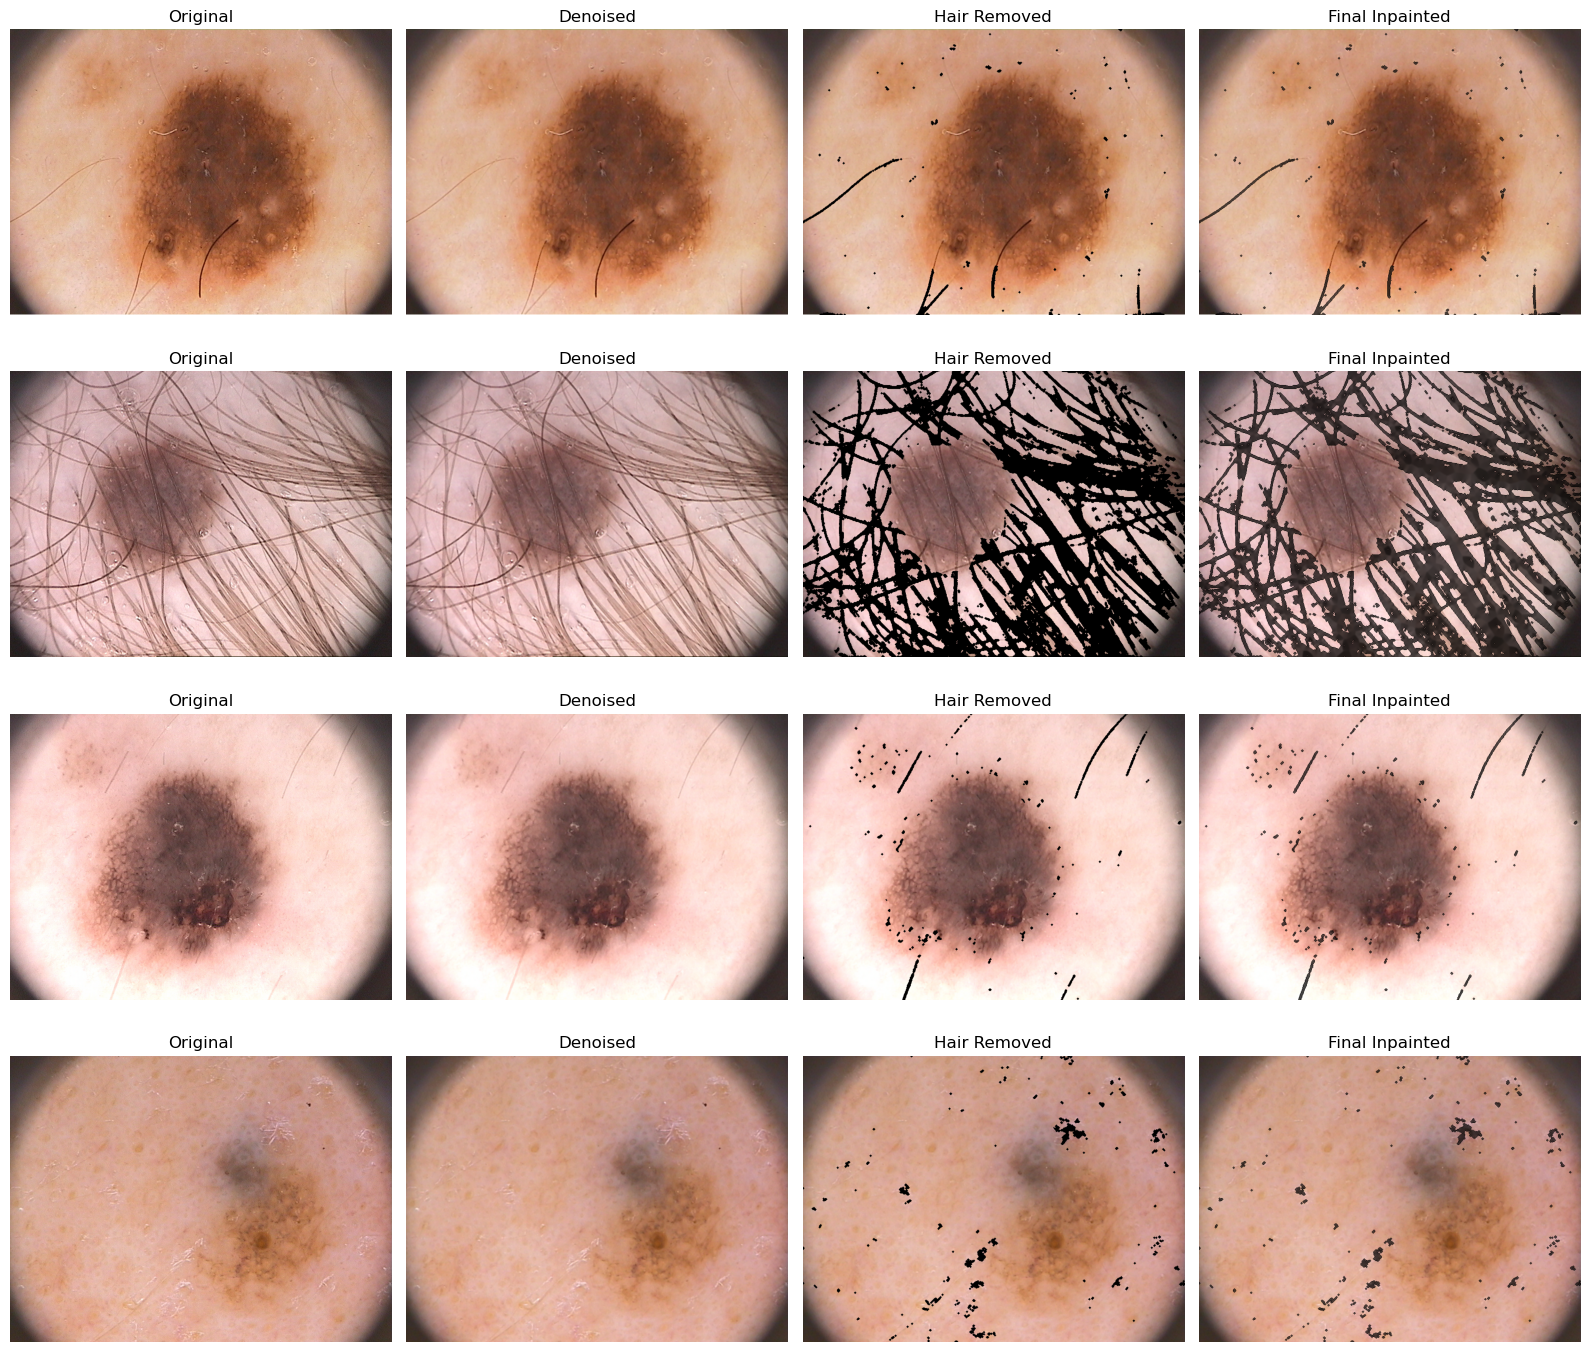

In [66]:
sample_files = input_images[:4]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for i, file in enumerate(sample_files):
    original = cv2.imread(str(file))
    denoised = cv2.imread(str(denoised_dir / file.name))
    hair_removed = cv2.imread(str(hair_removed_dir / file.name))
    final_image = cv2.imread(str(final_dir / file.name))

    images = [original, denoised, hair_removed, final_image]
    titles = ["Original", "Denoised", "Hair Removed", "Final Inpainted"]

    for j, (img, title) in enumerate(zip(images, titles)):
        axes[i, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i, j].set_title(title)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [69]:
# Save all Telea results

telea_dir = output_dir / "Telea"
telea_dir.mkdir(parents=True, exist_ok=True)

for i, file in enumerate(input_images):

    image_file = denoised_dir / file.name
    mask_file = hair_masks_dir / file.name

    image = cv2.imread(str(image_file))
    mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None:
        print("Skipped:", file.name)
        continue

    # Inpaint the hair areas directly
    telea_image = inpaint_image(image, mask, "Telea")

    cv2.imwrite(
        str(telea_dir / file.name),
        telea_image
    )

    if (i + 1) % 50 == 0 or i + 1 == len(input_images):
        print("Processed:", i + 1, "/", len(input_images))

print("Telea images saved in:", telea_dir)

Processed: 50 / 200
Processed: 100 / 200
Processed: 150 / 200
Processed: 200 / 200
Telea images saved in: ..\outputs\Telea
